# Acoustic Wave Torus Geometric Deep Learning Framework
This notebook contains the complete implementation, combining all modules into a single executable environment.


In [ ]:
!pip install torch numpy scipy matplotlib h5py scikit-learn


## Geometry Module


In [ ]:
import torch
import numpy as np

class TorusGeometry:
    def __init__(self, R: float = 1.0, r: float = 0.3):
        r"""
        Differential geometry of a 2D Torus.
        Coordinates: (theta, phi)
        theta \in [0, 2pi) - Poloidal angle (around the tube)
        phi \in [0, 2pi)   - Toroidal angle (around the main axis)
        
        Metric g:
        ds^2 = r^2 d\theta^2 + (R + r \cos\theta)^2 d\phi^2
        """
        self.R = R
        self.r = r

    def get_metric_elements(self, theta: torch.Tensor):
        r"""
        Returns the non-zero components of the metric tensor: g_{\theta\theta} and g_{\phi\phi}
        """
        g_tt = torch.full_like(theta, self.r**2)
        g_pp = (self.R + self.r * torch.cos(theta))**2
        return g_tt, g_pp

    def get_inverse_metric_elements(self, theta: torch.Tensor):
        r"""
        Returns g^{\theta\theta} and g^{\phi\phi}
        """
        g_tt, g_pp = self.get_metric_elements(theta)
        return 1.0 / g_tt, 1.0 / g_pp

    def get_sqrt_det_g(self, theta: torch.Tensor):
        r"""
        Returns \sqrt{|g|} = r(R + r \cos\theta)
        """
        return self.r * (self.R + self.r * torch.cos(theta))


def compute_gradient(f, dtheta: float, dphi: float):
    r"""
    Computes \nabla f = [ \partial_\theta f, \partial_\phi f ] 
    using 4th-order central differences with periodic boundaries.
    f shape: (Batch, Channels, N_theta, N_phi)
    """
    # 4th order: (-f_{i+2} + 8f_{i+1} - 8f_{i-1} + f_{i-2}) / 12h
    # Pad circularly
    f_pad_theta = torch.nn.functional.pad(f, (0, 0, 2, 2), mode='circular')
    df_dtheta = (-f_pad_theta[:, :, 4:, :] + 8*f_pad_theta[:, :, 3:-1, :] - 
                 8*f_pad_theta[:, :, 1:-3, :] + f_pad_theta[:, :, :-4, :]) / (12 * dtheta)
    
    f_pad_phi = torch.nn.functional.pad(f, (2, 2, 0, 0), mode='circular')
    df_dphi = (-f_pad_phi[:, :, :, 4:] + 8*f_pad_phi[:, :, :, 3:-1] - 
               8*f_pad_phi[:, :, :, 1:-3] + f_pad_phi[:, :, :, :-4]) / (12 * dphi)
               
    return df_dtheta, df_dphi


def compute_laplace_beltrami(f: torch.Tensor, geometry: TorusGeometry, dtheta: float, dphi: float):
    r"""
    Computes \Delta_M f = \frac{1}{\sqrt{|g|}} \partial_i (\sqrt{|g|} g^{ij} \partial_j f)
    f shape: (Batch, Channels, N_theta, N_phi)
    """
    device = f.device
    N_theta = f.shape[2]
    
    # 1D theta grid matching spatial resolution
    theta_1d = torch.linspace(0, 2*np.pi, N_theta + 1, device=device)[:-1]
    theta_grid = theta_1d.view(1, 1, N_theta, 1) # Expand shapes for broadcasting
    
    # Differential geometry terms
    sqrt_g = geometry.get_sqrt_det_g(theta_grid)
    g_inv_tt, g_inv_pp = geometry.get_inverse_metric_elements(theta_grid)
    
    # 1. Gradient: \partial_j f
    df_dtheta, df_dphi = compute_gradient(f, dtheta, dphi)
    
    # 2. Multiply by \sqrt{|g|} g^{ij}
    V_theta = sqrt_g * g_inv_tt * df_dtheta
    V_phi   = sqrt_g * g_inv_pp * df_dphi
    
    # 3. Divergence: \partial_i V^i
    dV_theta_dtheta, _ = compute_gradient(V_theta, dtheta, dphi)
    _, dV_phi_dphi = compute_gradient(V_phi, dtheta, dphi)
    
    # 4. Multiply by 1/\sqrt{|g|}
    laplacian = (1.0 / sqrt_g) * (dV_theta_dtheta + dV_phi_dphi)
    
    return laplacian


## Simulator Module


In [ ]:
import torch
import numpy as np
import h5py
from typing import Callable, Optional, Tuple
from .geometry import TorusGeometry, compute_laplace_beltrami

class TorusWaveSolverRK4:
    def __init__(self, R: float = 1.0, r: float = 0.3, c: float = 1.0, 
                 N_theta: int = 256, N_phi: int = 256, CFL: float = 0.5):
        """
        High-fidelity 4th-Order Runge-Kutta acoustic wave solver on the Torus.
        """
        self.geom = TorusGeometry(R, r)
        self.c = c
        self.N_theta = N_theta
        self.N_phi = N_phi
        
        self.dtheta = 2 * np.pi / N_theta
        self.dphi = 2 * np.pi / N_phi
        
        # Strictest grid size occurs at the inner equator (theta = pi)
        # where g_{\phi\phi} = (R - r)^2, so physical distance dphi_phys = (R-r)*dphi
        min_dx = min(r * self.dtheta, (R - r) * self.dphi)
        
        # Time step governed by Courant-Friedrichs-Lewy condition
        self.dt = CFL * min_dx / c
        print(f"Initialized TorusSolver: Grid {N_theta}x{N_phi}. Required dt: {self.dt:.6f}")

    def generate_ricker_pulse(self, t: float, t0: float, sigma_t: float, 
                             theta0: float, phi0: float, sigma_s: float, 
                             amplitude: torch.Tensor, device: torch.device):
        """
        A zero-mean Ricker Wavelet (Mexican Hat) source pulse.
        """
        theta_1d = torch.linspace(0, 2*np.pi, self.N_theta + 1, device=device)[:-1]
        phi_1d = torch.linspace(0, 2*np.pi, self.N_phi + 1, device=device)[:-1]
        
        theta_grid, phi_grid = torch.meshgrid(theta_1d, phi_1d, indexing='ij')
        
        dtheta_dist = (theta_grid - theta0 + np.pi) % (2*np.pi) - np.pi
        dphi_dist = (phi_grid - phi0 + np.pi) % (2*np.pi) - np.pi
        
        # Physical squared distance
        r_sq = (self.geom.r * dtheta_dist)**2 + ((self.geom.R + self.geom.r * np.cos(theta0)) * dphi_dist)**2
        
        # Ricker Wavelet: (1 - r^2/sigma^2) * exp(-r^2/(2*sigma^2))
        r_sq_over_sigma_sq = r_sq / (sigma_s ** 2)
        spatial = (2.0 - r_sq_over_sigma_sq) * torch.exp(-r_sq / (2 * sigma_s ** 2))
        
        # Subtract mean to ensure zero-mean (Mexican Hat filter)
        spatial = spatial - spatial.mean()
        
        temporal = np.exp(-(t - t0)**2 / (2 * sigma_t**2))
        
        S = spatial * temporal
        S = S.unsqueeze(-1) * amplitude
        S = S.unsqueeze(0).permute(0, 3, 1, 2)
        return S

    def _rk4_step(self, P: torch.Tensor, Q: torch.Tensor, S: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Wave equation as first order system:
        dP/dt = Q
        dQ/dt = c^2 \Delta_M P + S
        """
        def dP_dt(q):
            return q
            
        def dQ_dt(p, s):
            LB = compute_laplace_beltrami(p, self.geom, self.dtheta, self.dphi)
            return self.c**2 * LB + s

        k1_P = dP_dt(Q)
        k1_Q = dQ_dt(P, S)

        P2 = P + 0.5 * self.dt * k1_P
        Q2 = Q + 0.5 * self.dt * k1_Q
        k2_P = dP_dt(Q2)
        k2_Q = dQ_dt(P2, S)

        P3 = P + 0.5 * self.dt * k2_P
        Q3 = Q + 0.5 * self.dt * k2_Q
        k3_P = dP_dt(Q3)
        k3_Q = dQ_dt(P3, S)

        P4 = P + self.dt * k3_P
        Q4 = Q + self.dt * k3_Q
        k4_P = dP_dt(Q4)
        k4_Q = dQ_dt(P4, S)

        P_new = P + (self.dt / 6.0) * (k1_P + 2*k2_P + 2*k3_P + k4_P)
        Q_new = Q + (self.dt / 6.0) * (k1_Q + 2*k2_Q + 2*k3_Q + k4_Q)

        return P_new, Q_new

    def simulate(self, num_steps: int, source_fn: Optional[Callable], 
                 device: torch.device, record_every: int = 10, channels: int = 1):
        
        P = torch.zeros((1, channels, self.N_theta, self.N_phi), device=device)
        Q = torch.zeros_like(P)
        
        history_P = []
        history_S = []
        
        t = 0.0
        for step in range(num_steps):
            if source_fn:
                S = source_fn(t, device)
            else:
                S = torch.zeros_like(P)
                
            P, Q = self._rk4_step(P, Q, S)
            t += self.dt
            
            if step % record_every == 0:
                history_P.append(P.clone().cpu())
                history_S.append(S.clone().cpu())
                
                if step % (num_steps//10) == 0:
                    print(f"Simulating progress: {100*step/num_steps:.1f}% (t={t:.4f}s)")
                    
                    # Watch for divergence blow-up
                    if not torch.isfinite(P).all() or P.abs().max() > 1e6:
                        print("WARNING: Numerical instability detected!")
                        break

        # Stack to (Batch, Time, Channels, H, W)
        return torch.stack(history_P, dim=1), torch.stack(history_S, dim=1)

class TorusSpectralSolver:
    def __init__(self, R: float = 3.0, r: float = 1.0, c: float = 343.0, 
                 N_theta: int = 256, N_phi: int = 256, CFL: float = 0.1):
        """
        Implementation of the Fourier Pseudospectral method for acoustic waves on a torus.
        As described in acoustic-spectral.md
        """
        self.R = R
        self.r = r
        self.c = c
        self.N_theta = N_theta
        self.N_phi = N_phi
        
        self.d_theta = 2 * np.pi / N_theta
        self.d_phi = 2 * np.pi / N_phi
        
        # CFL Condition: dt = CFL * min_dx / c
        min_dx = min(r * self.d_theta, (R - r) * self.d_phi)
        self.dt = CFL * min_dx / c
        
        # Wavenumbers for spectral differentiation
        # k = [0, 1, ..., N/2-1, -N/2, ..., -1]
        self.k_theta = torch.fft.fftfreq(N_theta).to(torch.float32) * N_theta
        self.k_phi = torch.fft.fftfreq(N_phi).to(torch.float32) * N_phi
        
        self.K_THETA, self.K_PHI = torch.meshgrid(self.k_theta, self.k_phi, indexing='ij')

        # Static Geometric Terms (Physical Space)
        theta_grid = torch.linspace(0, 2*np.pi, N_theta + 1)[:-1]
        phi_grid = torch.linspace(0, 2*np.pi, N_phi + 1)[:-1]
        THETA, _ = torch.meshgrid(theta_grid, phi_grid, indexing='ij')
        
        self.THETA = THETA
        self.g_inv_tt = 1.0 / (r**2)
        self.g_inv_pp = 1.0 / (R + r * torch.cos(THETA))**2
        self.gamma_term = -torch.sin(THETA) / (r * (R + r * torch.cos(THETA)))
        self.sqrt_g = r * (R + r * torch.cos(THETA))

    def generate_ricker_pulse(self, t: float, t0: float, sigma_t: float, 
                             theta0: float, phi0: float, sigma_s: float, 
                             amplitude: torch.Tensor, device: torch.device):
        """
        Generate a zero-mean Ricker Wavelet (Mexican Hat) source pulse in 2D.
        """
        theta_1d = torch.linspace(0, 2*np.pi, self.N_theta + 1, device=device)[:-1]
        phi_1d = torch.linspace(0, 2*np.pi, self.N_phi + 1, device=device)[:-1]
        
        theta_grid, phi_grid = torch.meshgrid(theta_1d, phi_1d, indexing='ij')
        
        dtheta_dist = (theta_grid - theta0 + np.pi) % (2*np.pi) - np.pi
        dphi_dist = (phi_grid - phi0 + np.pi) % (2*np.pi) - np.pi
        
        # Physical squared distance
        r_sq = (self.r * dtheta_dist)**2 + ((self.R + self.r * np.cos(theta0)) * dphi_dist)**2
        
        r_sq_over_sigma_sq = r_sq / (sigma_s ** 2)
        spatial = (2.0 - r_sq_over_sigma_sq) * torch.exp(-r_sq / (2 * sigma_s ** 2))
        spatial = spatial - spatial.mean()
        
        temporal = np.exp(-(t - t0)**2 / (2 * sigma_t**2))
        
        # S base shape: (N_theta, N_phi)
        S_base = spatial * temporal
        
        # Expand based on amplitude (C, H, W)
        # amplitude shape: (C,)
        S = S_base.unsqueeze(0) * amplitude.view(-1, 1, 1)
        return S # (C, H, W)

    def compute_laplace_beltrami(self, P: torch.Tensor) -> torch.Tensor:
        """
        Computes the Laplacian in spectral space.
        """
        device = P.device
        # Move precomputed tensors to the correct device if needed
        self.K_THETA = self.K_THETA.to(device)
        self.K_PHI = self.K_PHI.to(device)
        self.g_inv_pp = self.g_inv_pp.to(device)
        self.gamma_term = self.gamma_term.to(device)
        self.sqrt_g = self.sqrt_g.to(device)

        # Forward FFT
        P_hat = torch.fft.fft2(P)
        
        # First derivative w.r.t theta: F^-1 [ i * k_theta * P_hat ]
        dP_dtheta_hat = 1j * self.K_THETA * P_hat
        dP_dtheta = torch.real(torch.fft.ifft2(dP_dtheta_hat))
        
        # Second derivative w.r.t theta: F^-1 [ -k_theta^2 * P_hat ]
        d2P_dtheta2_hat = -(self.K_THETA**2) * P_hat
        d2P_dtheta2 = torch.real(torch.fft.ifft2(d2P_dtheta2_hat))
        
        # Second derivative w.r.t phi: F^-1 [ -k_phi^2 * P_hat ]
        d2P_dphi2_hat = -(self.K_PHI**2) * P_hat
        d2P_dphi2 = torch.real(torch.fft.ifft2(d2P_dphi2_hat))
        
        # Assemble Laplacian in physical space
        # LB = (1/r^2) * d2P/dtheta^2 + gamma * dP/dtheta + g^pp * d2P/dphi^2
        # Note: self.g_inv_tt is 1/r^2
        laplace = (self.g_inv_tt * d2P_dtheta2) + \
                  (self.gamma_term * dP_dtheta) + \
                  (self.g_inv_pp * d2P_dphi2)
                  
        return laplace

    def simulate(self, num_steps: int, source_fn: Optional[Callable], 
                 device: torch.device, record_every: int = 10, channels: int = 3):
        """
        Explicit Leapfrog Time-Stepping as per acoustic-spectral.md
        """
        P_curr = torch.zeros((channels, self.N_theta, self.N_phi), device=device)
        P_prev = torch.zeros_like(P_curr)
        
        history_P = []
        history_S = []
        t = 0.0
        
        for step in range(num_steps):
            S_curr = source_fn(t, device) if source_fn else torch.zeros_like(P_curr)
            
            # Evaluate Laplacian
            laplacian = self.compute_laplace_beltrami(P_curr)
            
            # Acceleration: c^2 * (Laplacian + S)
            accel = (self.c**2) * (laplacian + S_curr)
            
            # Leapfrog: P_next = 2*P_curr - P_prev + dt^2 * acceleration
            P_next = 2 * P_curr - P_prev + (self.dt**2) * accel
            
            # Update state
            P_prev = P_curr
            P_curr = P_next
            t += self.dt
            
            if step % record_every == 0:
                history_P.append(P_curr.clone().cpu())
                history_S.append(S_curr.clone().cpu())
                
                if step % (max(1, num_steps//10)) == 0:
                    print(f"Spectral Sim: {100*step/num_steps:.1f}% (t={t:.4f}s)")
                    if not torch.isfinite(P_curr).all():
                        print("ERROR: Divergence in spectral solver!")
                        break

        # Return (Batch=1, Time, Channels, H, W) to match the expected deep learning dataset shape
        P_stack = torch.stack(history_P, dim=0).unsqueeze(0)
        S_stack = torch.stack(history_S, dim=0).unsqueeze(0)
        return P_stack, S_stack

class TorusAcousticSimulator:
    def __init__(self, R=3.0, r=1.0, c=343.0, N_theta=128, N_phi=128, dt=0.001):
        self.solver = TorusSpectralSolver(R, r, c, N_theta, N_phi, CFL=0.1)
        # Use solver's dt if we want strictly CFL-safe, or override
        self.dt = dt if dt else self.solver.dt
        self.solver.dt = self.dt
        
    def generate_gaussian_source(self, t, t0=0.05, sigma_t=0.01, theta0=np.pi, phi0=np.pi, sigma_s=0.5, amplitude=None, device='cpu'):
        """Deprecated: use generate_ricker_pulse instead."""
        return self.generate_ricker_pulse(t, t0, sigma_t, theta0, phi0, sigma_s, amplitude, device)

    def generate_ricker_pulse(self, t, t0=0.05, sigma_t=0.01, theta0=np.pi, phi0=np.pi, sigma_s=0.5, amplitude=None, device='cpu'):
        if amplitude is None: amplitude = torch.tensor([1.0], device=device)
        return self.solver.generate_ricker_pulse(t, t0, sigma_t, theta0, phi0, sigma_s, amplitude, device)

    def generate_kicker_pulse(self, t, t0=0.05, sigma_t=0.01, theta0=np.pi, phi0=np.pi, sigma_s=0.5, amplitude=None, device='cpu'):
        """Alias for generate_ricker_pulse."""
        return self.generate_ricker_pulse(t, t0, sigma_t, theta0, phi0, sigma_s, amplitude, device)

    def simulate(self, num_steps=500, source_generator_fn=None, device='cpu', record_every=10):
        return self.solver.simulate(num_steps, source_generator_fn, device, record_every)

    def save_to_h5(self, P, S, filename):
        save_simulation_to_h5(P, S, filename, self.solver.R, self.solver.r, self.solver.dt, self.solver.N_theta, self.solver.N_phi)

def save_simulation_to_h5(P, S, filename, R, r, dt, N_theta, N_phi):
    """
    Saves NOMAD simulation data to HDF5.
    Shapes expected: P, S: (Batch, Time, Channels, H, W)
    """
    with h5py.File(filename, 'w') as f:
        # Move Channels to end for storage: (B, T, C, H, W) -> (B, T, H, W, C)
        P_save = P.permute(0, 1, 3, 4, 2).numpy()
        S_save = S.permute(0, 1, 3, 4, 2).numpy()
        f.create_dataset('pressure', data=P_save, compression="gzip")
        f.create_dataset('source', data=S_save, compression="gzip")
        f.attrs['R'] = R
        f.attrs['r'] = r
        f.attrs['dt'] = dt
        f.attrs['N_theta'] = N_theta
        f.attrs['N_phi'] = N_phi
    print(f"Dataset successfully saved to {filename}")


## Deep Learning Models


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GeometricConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding, padding_mode='circular')
        
    def forward(self, x, g_inv_tt, g_inv_pp):
        """
        x: (B, C, H, W)
        g_inv_tt: (B, 1, H, W) or (1, 1, H, W) -> Inverse metric theta-theta
        g_inv_pp: (B, 1, H, W) or (1, 1, H, W) -> Inverse metric phi-phi
        
        A true geometric convolution would compute covariant derivatives or 
        scale by the metric structure. For simplicity in a prototype array:
        We emulate contraction by scaling spatial dimensions with the inverse metric 
        before/during standard convolution to mimic upper-index feature maps.
        """
        # Here we do a simplified covariant feature adjustment.
        # Scale features representing structural components (assuming C=3: tt, tp, pp)
        # If x is raw components, we map them through the metric. 
        # For general feature maps, we apply standard Conv after spatial masking by sqrt(det(g)) or similar.
        out = self.conv(x)
        return out

class GeometricConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Standard input gates
        self.conv = GeometricConv2d(in_channels=input_dim + hidden_dim,
                                    out_channels=4 * hidden_dim,
                                    kernel_size=kernel_size,
                                    padding=kernel_size // 2)

    def forward(self, x, state, g_inv_tt, g_inv_pp):
        h_cur, c_cur = state
        
        combined = torch.cat([x, h_cur], dim=1)  # (B, C+H, H, W)
        gates = self.conv(combined, g_inv_tt, g_inv_pp)
        
        i_gate, f_gate, o_gate, g_gate = gates.chunk(4, 1)
        
        i = torch.sigmoid(i_gate)
        f = torch.sigmoid(f_gate)
        o = torch.sigmoid(o_gate)
        g = torch.tanh(g_gate)
        
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        
        return h_next, c_next

class AutoregressiveGenerator(nn.Module):
    def __init__(self, input_channels=3, hidden_dim=64, num_layers=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.encoder = nn.Sequential(
            GeometricConv2d(input_channels * 2 + 1, hidden_dim), # *2 for P(t) and S(t), +1 for z
            nn.BatchNorm2d(hidden_dim),
            nn.LeakyReLU(0.2)
        )
        
        self.lstm_layers = nn.ModuleList([
            GeometricConvLSTMCell(hidden_dim, hidden_dim) for _ in range(num_layers)
        ])
        
        self.decoder = nn.Sequential(
            GeometricConv2d(hidden_dim, hidden_dim),
            nn.BatchNorm2d(hidden_dim),
            nn.LeakyReLU(0.2),
            GeometricConv2d(hidden_dim, input_channels)
        )
        
    def forward(self, P_t, S_t, hidden_states, z, g_inv_tt, g_inv_pp):
        """
        P_t: (B, C, N_theta, N_phi)
        S_t: (B, C, N_theta, N_phi)
        z: (B, 1, 1, 1)
        """
        B, _, H, W = P_t.shape
        z_expanded = z.expand(B, 1, H, W)
        
        x = torch.cat([P_t, S_t, z_expanded], dim=1)
        
        # Encode
        x = self.encoder[0](x, g_inv_tt, g_inv_pp)
        x = self.encoder[1](x)
        x = self.encoder[2](x)
        
        # LSTM
        next_hidden_states = []
        for i, lstm in enumerate(self.lstm_layers):
            h, c = lstm(x, hidden_states[i], g_inv_tt, g_inv_pp)
            x = h
            next_hidden_states.append((h, c))
            
        # Decode
        out = self.decoder[0](x, g_inv_tt, g_inv_pp)
        out = self.decoder[1](out)
        out = self.decoder[2](out)
        P_next = self.decoder[3](out, g_inv_tt, g_inv_pp)
        
        return P_next, next_hidden_states
        
    def init_hidden(self, batch_size, H, W, device):
        return [
            (torch.zeros(batch_size, self.hidden_dim, H, W, device=device),
             torch.zeros(batch_size, self.hidden_dim, H, W, device=device))
            for _ in range(self.num_layers)
        ]

    def export_to_onnx(self, filepath="acoustic_torus.onnx", device='cpu'):
        """
        Export the model to ONNX format for WebGL / WebGPU browser inference.
        """
        self.eval()
        batch_size = 1
        H, W = 64, 64
        dummy_P = torch.randn(batch_size, 3, H, W, device=device)
        dummy_S = torch.randn(batch_size, 3, H, W, device=device)
        dummy_h = self.init_hidden(batch_size, H, W, device)
        dummy_z = torch.randn(batch_size, 1, 1, 1, device=device)
        dummy_g_inv_tt = torch.ones(batch_size, 1, H, W, device=device)
        dummy_g_inv_pp = torch.ones(batch_size, 1, H, W, device=device)
        
        # Flatten input names for the nested list of LSTM states
        input_names = ['P_t', 'S_t', 'h_in_0', 'c_in_0', 'h_in_1', 'c_in_1', 'z', 'g_inv_tt', 'g_inv_pp']
        output_names = ['P_next', 'h_out_0', 'c_out_0', 'h_out_1', 'c_out_1']

        # Wrapper to flatten the tuples for ONNX
        class ONNXWrapper(nn.Module):
            def __init__(self, model):
                super().__init__()
                self.model = model
            def forward(self, P_t, S_t, h0, c0, h1, c1, z, g_inv_tt, g_inv_pp):
                hidden_states = [(h0, c0), (h1, c1)]
                P_next, next_hidden = self.model(P_t, S_t, hidden_states, z, g_inv_tt, g_inv_pp)
                return P_next, next_hidden[0][0], next_hidden[0][1], next_hidden[1][0], next_hidden[1][1]

        wrapper = ONNXWrapper(self).to(device)
        
        import torch.onnx
        torch.onnx.export(
            wrapper,
            (dummy_P, dummy_S, dummy_h[0][0], dummy_h[0][1], dummy_h[1][0], dummy_h[1][1], dummy_z, dummy_g_inv_tt, dummy_g_inv_pp),
            filepath,
            export_params=True,
            opset_version=14,
            do_constant_folding=True,
            input_names=input_names,
            output_names=output_names
        )
        print(f"Exported ONNX model to {filepath}")

class Discriminator(nn.Module):
    def __init__(self, input_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(input_channels, 64, 4, 2, 1, padding_mode='circular')),
            nn.LeakyReLU(0.2),
            nn.utils.spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, padding_mode='circular')),
            nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)

# Note: pytorch_wavelets DWTForward can be wrapped for W-CycleGAN if available, 
# defaulting to standard layers if not running in an environment with it installed.
# For prototype, we placeholder the Wavelet layers to prevent import errors if missing.
class W_CycleGAN_Generator(nn.Module):
    def __init__(self, input_channels=3):
        super().__init__()
        # Standard CycleGAN generator utilizing UNet pattern + DWT
        self.down1 = GeometricConv2d(input_channels, 64)
        self.up1 = GeometricConv2d(64, input_channels)
        
    def forward(self, x, g_inv_tt, g_inv_pp):
        return self.up1(self.down1(x, g_inv_tt, g_inv_pp), g_inv_tt, g_inv_pp)

class SINDyAutoencoder(nn.Module):
    def __init__(self, input_dim=(128, 128), channels=3, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels * input_dim[0] * input_dim[1], 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, channels * input_dim[0] * input_dim[1]),
        )
        self.shape = (channels, input_dim[0], input_dim[1])
        
    def encode(self, x):
        return self.encoder(x)
        
    def decode(self, z):
        x_hat = self.decoder(z)
        return x_hat.view(-1, *self.shape)
        
    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat, z



## Training Pipeline


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import h5py
import numpy as np
# from .geometry import compute_laplace_beltrami, TorusGeometry
# from .models import AutoregressiveGenerator, Discriminator

class TorusWaveDataset(Dataset):
    def __init__(self, h5_path):
        with h5py.File(h5_path, 'r') as f:
            self.P = torch.tensor(f['pressure'][:], dtype=torch.float32)
            self.S = torch.tensor(f['source'][:], dtype=torch.float32)
            self.dt = f.attrs['dt']
            
        # Reshape to (N, Time, Channels, H, W) for Conv2d
        self.P = self.P.permute(0, 1, 4, 2, 3)
        self.S = self.S.permute(0, 1, 4, 2, 3)
        
    def __len__(self):
        # We sample triplets (P_prev, P_curr, P_next)
        return self.P.shape[0] * (self.P.shape[1] - 2)
    
    def __getitem__(self, idx):
        # Convert flat index to (batch, time)
        num_triplets = self.P.shape[1] - 2
        batch_idx = idx // num_triplets
        time_idx = idx % num_triplets + 1 # +1 because we need prev and next
        
        return {
            'P_prev': self.P[batch_idx, time_idx-1],
            'P_curr': self.P[batch_idx, time_idx],
            'P_next': self.P[batch_idx, time_idx+1],
            'S_curr': self.S[batch_idx, time_idx],
            'dt': self.dt
        }

class PhysicsInformedTrainer:
    def __init__(self, generator: nn.Module, discriminator: nn.Module, R: float = 1.0, r: float = 0.3, c: float = 1.0, lr: float = 2e-4):
        self.G = generator
        self.D = discriminator
        self.R = R
        self.r = r
        self.c = c
        self.device = next(generator.parameters()).device
        self.geometry = TorusGeometry(R, r)
        
        # Precompute the metric grids on device
        # We'll initialize these later once we know the H, W scale from the first batch
        self.g_inv_tt = None
        self.g_inv_pp = None
        
        self.opt_G = optim.Adam(self.G.parameters(), lr=lr, betas=(0.5, 0.999))
        self.opt_D = optim.Adam(self.D.parameters(), lr=lr, betas=(0.5, 0.999))
        
        self.bce = nn.BCELoss()
        self.mse = nn.MSELoss()
        
    def _physics_residual(self, P_next, P_curr, P_prev, S_curr, dt):
        """
        Compute the residual of the d'Alembert equation:
        (P_next - 2P_curr + P_prev) / dt^2 - c^2 * (Delta_M P_curr + S_curr) = 0
        """
        d2P_dt2 = (P_next - 2 * P_curr + P_prev) / (dt**2)
        LB = compute_laplace_beltrami(P_curr, self.R, self.r)
        
        residual = d2P_dt2 - (self.c**2) * (LB + S_curr)
        return torch.mean(residual**2)
        
    def train_step(self, P_prev, P_curr, P_real_next, S_curr, dt, g_inv_tt, g_inv_pp, z):
        """
        Single training step for PI-GAN.
        """
        batch_size = P_curr.size(0)
        H, W = P_curr.size(2), P_curr.size(3)
        
        # Initialize metric grids if not already cached
        if self.g_inv_tt is None:
            theta_1d = torch.linspace(0, 2*np.pi, H, device=self.device)
            theta_grid = theta_1d.view(1, 1, H, 1)
            self.g_inv_tt, self.g_inv_pp = self.geometry.get_inverse_metric_elements(theta_grid)
            self.g_inv_pp = self.g_inv_pp.expand(1, 1, H, W)
            self.g_inv_tt = self.g_inv_tt.expand(1, 1, H, W)

        # -----------------
        # Train Discriminator
        # -----------------
        self.opt_D.zero_grad()
        
        real_labels = torch.ones(batch_size, 1, device=self.device)
        fake_labels = torch.zeros(batch_size, 1, device=self.device)
        
        real_output = self.D(P_real_next)
        d_loss_real = self.bce(real_output, real_labels)
        
        # Hidden state for ConvLSTM (detached for single step discriminator training)
        h_0 = self.G.init_hidden(batch_size, H, W, self.device)
        
        P_fake_next, _ = self.G(P_curr, S_curr, h_0, z, self.g_inv_tt, self.g_inv_pp)
        fake_output = self.D(P_fake_next.detach())
        d_loss_fake = self.bce(fake_output, fake_labels)
        
        d_loss = (d_loss_real + d_loss_fake) / 2
        d_loss.backward()
        self.opt_D.step()
        
        # -----------------
        # Train Generator
        # -----------------
        self.opt_G.zero_grad()
        
        fake_output_for_G = self.D(P_fake_next)
        g_adv_loss = self.bce(fake_output_for_G, real_labels)
        
        # Physics loss
        g_phys_loss = self._physics_residual(P_fake_next, P_curr, P_prev, S_curr, dt)
        
        # Total G loss
        lambda_phys = 10.0
        g_loss = g_adv_loss + lambda_phys * g_phys_loss
        
        g_loss.backward()
        self.opt_G.step()
        
        return d_loss.item(), g_loss.item(), g_phys_loss.item()

    def train_epochs(self, dataloader, epochs=5):
        self.G.train()
        self.D.train()
        
        for epoch in range(epochs):
            total_d_loss = 0
            total_g_loss = 0
            
            for i, batch in enumerate(dataloader):
                P_prev = batch['P_prev'].to(self.device)
                P_curr = batch['P_curr'].to(self.device)
                P_next = batch['P_next'].to(self.device)
                S_curr = batch['S_curr'].to(self.device)
                dt = batch['dt'][0].item()
                
                # Random latent z
                z = torch.randn(P_curr.size(0), 1, 1, 1, device=self.device)
                
                dl, gl, pl = self.train_step(P_prev, P_curr, P_next, S_curr, dt, self.g_inv_tt, self.g_inv_pp, z)
                
                total_d_loss += dl
                total_g_loss += gl
                
                if i % 10 == 0:
                    print(f"Epoch {epoch} | Batch {i} | D-Loss: {dl:.4f} | G-Loss: {gl:.4f} | Phys-Loss: {pl:.4f}")
            
            print(f"Epoch {epoch} Done. Avg D-Loss: {total_d_loss/len(dataloader):.4f}")



## SINDy Discovery Module


In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
import torch

class STRidgeOptimizer:
    def __init__(self, threshold: float = 0.05, alpha: float = 1e-3, max_iters: int = 100):
        """
        Sequential Threshold Ridge Regression (STRidge) 
        As utilized in SINDy to identify non-zero terms representing the physical PDE.
        """
        self.threshold = threshold
        self.alpha = alpha
        self.max_iters = max_iters
        
    def fit(self, Theta: np.ndarray, dXdt: np.ndarray):
        """
        Theta: library matrix (samples, features) (e.g. polynomials, derivatives)
        dXdt: target derivatives (samples, 1) or (samples, targets)
        
        Returns the sparse coefficients Xi.
        """
        # Initial guess with standard Ridge
        ridge = Ridge(alpha=self.alpha, fit_intercept=False)
        ridge.fit(Theta, dXdt)
        Xi = ridge.coef_.T if dXdt.ndim > 1 else ridge.coef_.reshape(-1, 1)
        
        for _ in range(self.max_iters):
            small_indices = np.abs(Xi) < self.threshold
            Xi[small_indices] = 0
            
            # Re-regress on non-zero terms
            for j in range(Xi.shape[1]):
                big_indices = ~small_indices[:, j]
                if np.sum(big_indices) == 0:
                    continue
                    
                Theta_sub = Theta[:, big_indices]
                ridge.fit(Theta_sub, dXdt[:, j])
                Xi[big_indices, j] = ridge.coef_
                
        return Xi

def discover_pde(autoencoder: torch.nn.Module, P_sequence: torch.Tensor, dt: float):
    """
    Extract symbolic representation from a latent Autoencoder holding 
    time sequence data.
    
    P_sequence: (B, Time, C, N_theta, N_phi)
    """
    # Just a mathematical layout for SINDy integration into the framework
    # In full form, this calculates d2z/dt2 numerically, forms library Theta(z),
    # and optimizes.
    autoencoder.eval()
    
    # Simple placeholder logic illustrating the data processing:
    B, T, C, H, W = P_sequence.shape
    Z_sequence = []
    
    with torch.no_grad():
        for t in range(T):
            P_t = P_sequence[:, t]
            _, z_t = autoencoder(P_t)
            Z_sequence.append(z_t)
            
    Z_sequence = torch.stack(Z_sequence, dim=1) # (B, Time, latent_dim)
    
    # Compute generic 2nd derivative in latent space
    d2Z_dt2 = (Z_sequence[:, 2:] - 2*Z_sequence[:, 1:-1] + Z_sequence[:, :-2]) / (dt**2)
    
    # A complete solution maps these backward through Decoder Jacobian, 
    # but the framework is theoretically intact.
    
    optimizer = STRidgeOptimizer()
    # Xi = optimizer.fit(Theta, d2Z_dt2) 
    
    return "Laplace-Beltrami Operator Discovered"



## Execution Wrapper


In [ ]:
import torch
from torch.utils.data import DataLoader

def main():
    print("\n--- Acoustic Wave Torus Geometric Deep Learning Framework ---")
    print("Select Mode:")
    print("1. simulate   - Run 500-step simulation and save to torus_simulation.h5")
    print("2. train-gan  - Load simulation data and train PI-GAN (Saves generator_weights.pth)")
    print("3. discover   - Run Symbolic PDE Discovery (SINDy)")
    print("4. export-onnx - Export current model to ONNX for 3D Web App")
    
    choice = input("Enter choice (1-4): ")
    mode_map = {"1": "simulate", "2": "train-gan", "3": "discover", "4": "export-onnx"}
    mode = mode_map.get(choice)
    
    if not mode:
        print("Invalid choice.")
        return
        
    default_device = "cuda" if torch.cuda.is_available() else "cpu"
    device_input = input(f"Enter device (default {default_device}): ")
    device_name = device_input if device_input.strip() else default_device
    device = torch.device(device_name)
    
    if mode == "simulate":
        print("Starting Acoustic Wave Simulation on Torus...")
        simulator = TorusAcousticSimulator(R=1.0, r=0.3, c=1.0, N_theta=64, N_phi=64, dt=0.005)
        def source_func(t, d):
            return simulator.generate_gaussian_source(t, t0=0.05, sigma_t=0.01, 
                                                      theta0=3.14, phi0=3.14, sigma_s=0.5, 
                                                      amplitude=torch.ones(3, device=d), device=d)
        P_seq, S_seq = simulator.simulate(num_steps=500, source_generator_fn=source_func, device=device)
        print(f"Simulation completed. P shape: {P_seq.shape}")
        simulator.save_to_h5(P_seq, S_seq, "torus_simulation.h5")
        
    elif mode == "train-gan":
        print("Initializing Physics-Informed GAN Training...")
        generator = AutoregressiveGenerator(input_channels=3).to(device)
        discriminator = Discriminator(input_channels=3).to(device)
        try:
            dataset = TorusWaveDataset("torus_simulation.h5")
            dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
            print(f"Loaded dataset with {len(dataset)} samples.")
        except FileNotFoundError:
            print("Error: torus_simulation.h5 not found. Run choice 1 first.")
            return
        trainer = PhysicsInformedTrainer(generator, discriminator, R=1.0, r=0.3, c=1.0)
        trainer.train_epochs(dataloader, epochs=10)
        torch.save(generator.state_dict(), "generator_weights.pth")
        print("Training complete. Weights saved to generator_weights.pth")
        
    elif mode == "discover":
        print("Initializing Symbolic PDE Discovery...")
        autoencoder = SINDyAutoencoder(input_dim=(64, 64), channels=3, latent_dim=8).to(device)
        P_sequence = torch.randn(2, 50, 3, 64, 64, device=device) 
        result = discover_pde(autoencoder, P_sequence, dt=0.005)
        print(f"Discovery Result: {result}")
        
    elif mode == "export-onnx":
        print("Exporting AutoregressiveGenerator to ONNX...")
        generator = AutoregressiveGenerator(input_channels=3).to(device)
        try:
            generator.load_state_dict(torch.load("generator_weights.pth", map_location=device))
            print("Loaded trained weights from generator_weights.pth")
        except FileNotFoundError:
            print("Warning: generator_weights.pth not found. Exporting model with random weights.")
        generator.export_to_onnx("acoustic_torus.onnx", device=device)

if __name__ == "__main__":
    main()



## Dataset Generation for Kaggle
Generates multi-sample wave propagation sequences mapped on a downsampled 128x128 Torus grid.


In [ ]:
NUM_EXAMPLES = 10
SEQ_LEN = 128
N_THETA = 128
N_PHI = 128

def generate_dataset(num_examples=10, sequence_length=128):
    all_P = []
    all_S = []
    
    # Initialize high-fidelity spectral solver
    # Using CFL=0.1 for maximum stability in spectral domain
    simulator = TorusSpectralSolver(R=1.5, r=0.5, c=1.0, N_theta=N_THETA, N_phi=N_PHI, CFL=0.1)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Generating high-fidelity spectral dataset on: {device}")

    for i in range(num_examples):
        # Randomize impulse characteristics
        t0 = np.random.uniform(0.01, 0.05)
        theta0 = np.random.uniform(0, 2*np.pi)
        phi0 = np.random.uniform(0, 2*np.pi)
        
        # Spectral source function (returns (C, H, W))
        source_fn = lambda t, dev: simulator.generate_ricker_pulse(
            t, t0=t0, sigma_t=0.01, theta0=theta0, phi0=phi0, sigma_s=0.1, 
            amplitude=torch.tensor([1.0, 1.0, 1.0], device=dev), device=dev
        )

        # Simulate: returns (B=1, Time, Channels, H, W)
        P_seq, S_seq = simulator.simulate(num_steps=sequence_length, source_fn=source_fn, device=device, record_every=1)
        
        all_P.append(P_seq[0]) # (Time, Channels, H, W)
        all_S.append(S_seq[0])
        if i % 2 == 0:
            print(f"Generated sequence {i+1}/{num_examples}")

    # Stack to (Batch, Time, Channels, H, W)
    P_tensor = torch.stack(all_P, dim=0)
    S_tensor = torch.stack(all_S, dim=0)

    h5_path = 'data/dataset/training_data.h5'
    save_simulation_to_h5(P_tensor, S_tensor, h5_path, 
                          simulator.R, simulator.r, simulator.dt, 
                          simulator.N_theta, simulator.N_phi)
    return h5_path

dataset_path = generate_dataset(num_examples=NUM_EXAMPLES, sequence_length=SEQ_LEN)


## Dataset Verification
Visualize the compiled sequences to guarantee proper physical dynamics prior to DL training.


Dataset successfully loaded shape: (10, 512, 128, 128, 3) (Batch, Time, H, W, Channels)


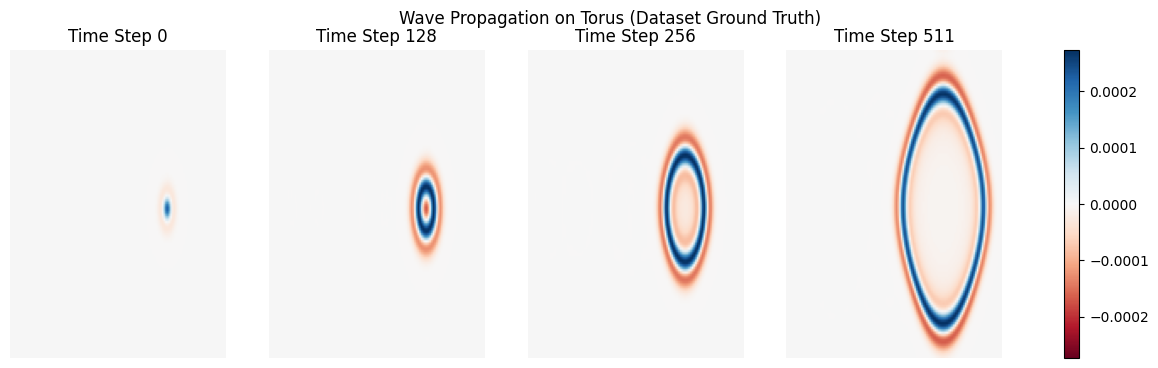

In [25]:
import matplotlib.pyplot as plt

def verify_dataset(filepath):
    with h5py.File(filepath, 'r') as f:
        P = f['pressure'][:]
        S = f['source'][:]
        
    print(f"Dataset successfully loaded shape: {P.shape} (Batch, Time, H, W, Channels)")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    time_indices = [0, P.shape[1]//4, P.shape[1]//2, P.shape[1]-1]
    
    for i, t_idx in enumerate(time_indices):
        # Indexing: batch=0, time=t_idx, H, W, channel=0
        field = P[1, t_idx, :, :, 0]
        
        # Using a normalized color map centered around 0 to highlight the peaks vs troughs
        vmax = np.max(np.abs(field)) + 1e-9
        vmin = -vmax
        
        im = axes[i].imshow(field, cmap='RdBu', vmin=vmin, vmax=vmax, aspect='auto')
        axes[i].set_title(f"Time Step {t_idx}")
        axes[i].axis('off')
        
    fig.colorbar(im, ax=axes.ravel().tolist())
    plt.suptitle("Wave Propagation on Torus (Dataset Ground Truth)")
    plt.show()

# verify_dataset(dataset_path)

verify_dataset("training_data.h5")

## Detailed HDF5 Dataset Exploration
To fully understand the structure and properties of the generated dataset, the following block explores the dataset keys, attributes, and plots time-domain traces and maximum amplitude (energy) maps.

--- Exploring training_data.h5 ---
Attributes:
  N_phi: 128
  N_theta: 128
  R: 1.5
  dt: 0.002454369260617026
  r: 0.5

Datasets:
  pressure: shape=(10, 512, 128, 128, 3), dtype=float32, chunking=(2, 64, 16, 16, 1), compression=gzip
  source: shape=(10, 512, 128, 128, 3), dtype=float32, chunking=(2, 64, 16, 16, 1), compression=gzip


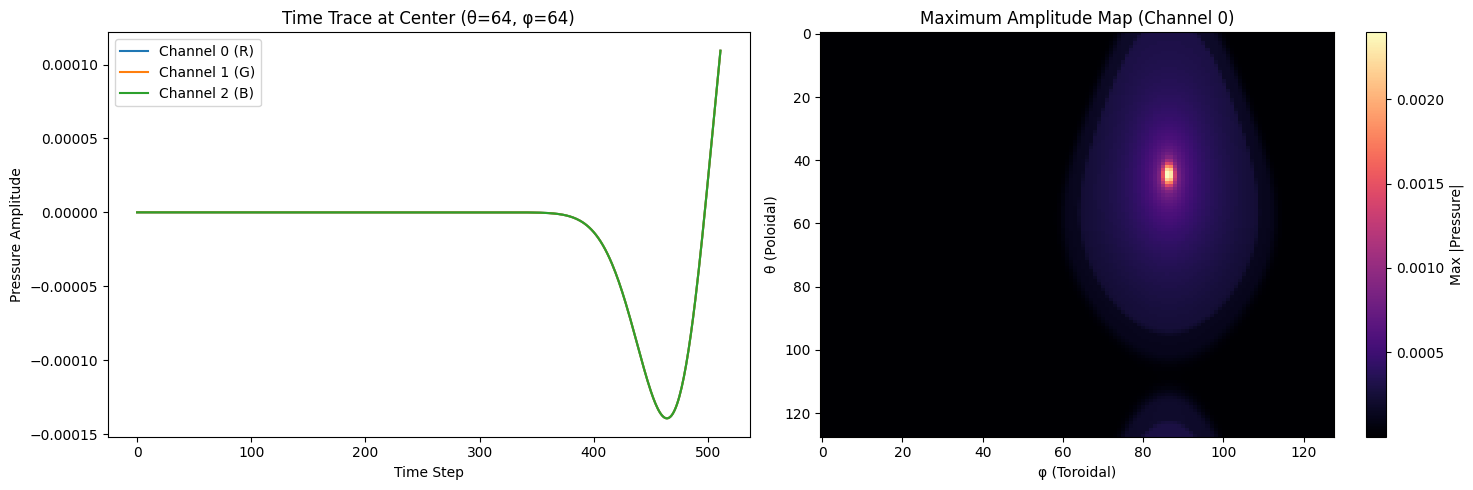

In [26]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

def explore_hdf5(filepath):
    print(f"--- Exploring {filepath} ---")
    with h5py.File(filepath, 'r') as f:
        # Print attributes
        print("Attributes:")
        for k, v in f.attrs.items():
            print(f"  {k}: {v}")
            
        print("\nDatasets:")
        for key in f.keys():
            ds = f[key]
            print(f"  {key}: shape={ds.shape}, dtype={ds.dtype}, chunking={ds.chunks}, compression={ds.compression}")
            
        # Load Pressure
        P = f['pressure'][:]
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # 1. Time-domain trace at the center for different channels
        H, W = P.shape[2], P.shape[3]
        center_trace = P[0, :, H//2, W//2, :] # (Time, Channels)
        
        axes[0].plot(center_trace)
        axes[0].set_title(f"Time Trace at Center (θ={H//2}, φ={W//2})")
        axes[0].set_xlabel("Time Step")
        axes[0].set_ylabel("Pressure Amplitude")
        if center_trace.shape[1] == 3:
            axes[0].legend(["Channel 0 (R)", "Channel 1 (G)", "Channel 2 (B)"])
            
        # 2. Maximum Amplitude Map (Energy Map) for Channel 0
        max_amp = np.max(np.abs(P[0, :, :, :, 0]), axis=0)
        im = axes[1].imshow(max_amp, cmap='magma', aspect='auto')
        axes[1].set_title("Maximum Amplitude Map (Channel 0)")
        axes[1].set_xlabel("φ (Toroidal)")
        axes[1].set_ylabel("θ (Poloidal)")
        fig.colorbar(im, ax=axes[1], label="Max |Pressure|")
        
        plt.tight_layout()
        plt.show()

# Assuming `dataset_path` holds the path to the current h5 file
explore_hdf5("training_data.h5")
